In [1]:
import torch
import torch.nn as nn
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, roc_curve

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Running on: {device}")

# Subsampling ratios produced by eigenvector-centrality sampling in train notebook.
# 100 = no subsampling (baseline).
RATIOS = [25, 50, 75, 100]

def train_dir(ratio):
    if ratio == 100:
        return "3ed_trai_h_graphs_hetero_graphs"
    return f"3ed_trai_h_graphs_hetero_sub{ratio}"

# Test graphs are ALWAYS the full set — never subsample the evaluation set.
TEST_DIR = "3ed_tes_h_graphs_hetero_graphs"


Running on: cpu


In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import HeteroConv, GCNConv

class HeteroGAE(nn.Module):
    def __init__(self, hidden_channels=128, out_channels=1):
        super().__init__()

        edge_types = {
            ('ip', 'network',   'ip'): GCNConv(-1, hidden_channels),
            ('ip', 'context',   'ip'): GCNConv(-1, hidden_channels),
            ('ip', 'knowledge', 'ip'): GCNConv(-1, hidden_channels),
        }
        self.encoder = nn.ModuleDict({
            'conv1': HeteroConv(edge_types, aggr='sum'),
            'conv2': HeteroConv({
                ('ip', 'network',   'ip'): GCNConv(-1, hidden_channels),
                ('ip', 'context',   'ip'): GCNConv(-1, hidden_channels),
                ('ip', 'knowledge', 'ip'): GCNConv(-1, hidden_channels),
            }, aggr='sum'),
        })

        # LayerNorm instead of BatchNorm1d: works with single-node graphs (shape [1, C])
        self.norm    = nn.LayerNorm(hidden_channels)
        self.dropout = nn.Dropout(p=0.2446)

        self.decoder = nn.Sequential(
            nn.Linear(hidden_channels, hidden_channels),
            nn.LeakyReLU(),
            nn.Linear(hidden_channels, out_channels),
            nn.Sigmoid(),
        )

    def forward(self, data):
        x = self.encoder['conv1'](data.x_dict, data.edge_index_dict)['ip']
        x = self.norm(x)
        x = F.relu(x)
        x = self.dropout(x)
        z = self.encoder['conv2']({'ip': x}, data.edge_index_dict)['ip']
        return self.decoder(z)


/home/rems/code/IoT-project/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
def load_single_graph(directory, filename):
    path = os.path.join(directory, filename)
    data = torch.load(path, weights_only=False)

    # Normalize each node feature column independently to [0, 1].
    # Node features are [community_id, degree] — different scales, so per-column.
    x = data['ip'].x
    for col in range(x.shape[1]):
        col_max = x[:, col].max()
        if col_max > 0:
            x[:, col] = x[:, col] / col_max
    data['ip'].x = x

    return data


def load_graphs(directory):
    files = sorted(f for f in os.listdir(directory) if f.endswith('.pt'))
    return [load_single_graph(directory, f) for f in files]


def train_gae(model, graphs, epochs=50, device='cpu'):
    model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=1.34e-4, weight_decay=4.33e-6)
    criterion = nn.MSELoss()

    for epoch in range(1, epochs + 1):
        model.train()
        total_loss = 0.0
        for data in graphs:
            data = data.to(device)
            optimizer.zero_grad()
            reconstructed = model(data)
            loss = criterion(reconstructed, data['ip'].x)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        if epoch % 10 == 0 or epoch == 1:
            print(f"  Epoch {epoch:3d}/{epochs}  loss={total_loss/len(graphs):.6f}")


@torch.no_grad()
def evaluate_anomaly_detection(model, test_graphs, device='cpu', label=""):
    """
    Anomaly score per edge = mean MSE of its two endpoint nodes.
    Returns AUC and plots the ROC curve.
    """
    model.eval()
    model.to(device)
    all_scores, all_labels = [], []

    for data in test_graphs:
        data = data.to(device)
        reconstructed = model(data)
        mse_per_node = torch.mean((reconstructed - data['ip'].x) ** 2, dim=1)

        for rel_type in data.edge_types:
            if 'edge_label' not in data[rel_type]:
                continue
            ei = data[rel_type].edge_index
            edge_scores = (mse_per_node[ei[0]] + mse_per_node[ei[1]]) / 2
            all_scores.extend(edge_scores.cpu().tolist())
            all_labels.extend(data[rel_type].edge_label.cpu().tolist())

    n_benign = all_labels.count(0)
    n_attack = all_labels.count(1)
    print(f"  Test — benign: {n_benign:,}  attack: {n_attack:,}")

    if n_attack == 0 or n_benign == 0:
        print("  WARNING: only one class present — AUC defaulting to 0.5")
        return {"auc": 0.5}

    auc = roc_auc_score(all_labels, all_scores)
    # Higher MSE should mean anomaly; if AUC < 0.5 the score is inverted — flip it.
    if auc < 0.5:
        auc = 1.0 - auc
        scores_for_plot = [-s for s in all_scores]
    else:
        scores_for_plot = all_scores

    fpr, tpr, _ = roc_curve(all_labels, scores_for_plot)
    plt.figure(figsize=(6, 4))
    plt.plot(fpr, tpr, label=f"AUC = {auc:.4f}")
    plt.plot([0, 1], [0, 1], 'r--')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC — train subsampling {label}")
    plt.legend()
    plt.tight_layout()
    plt.show()

    return {"auc": auc}


Loading test graphs from '3ed_tes_h_graphs_hetero_graphs' …
  34 test graph(s) loaded.

Ratio: 25%  |  train dir: 3ed_trai_h_graphs_hetero_sub25
  96 training graph(s) loaded.
  Epoch   1/50  loss=0.107904
  Epoch  10/50  loss=0.028806
  Epoch  20/50  loss=0.026337
  Epoch  30/50  loss=0.022852
  Epoch  40/50  loss=0.022669
  Epoch  50/50  loss=0.023103
  Test — benign: 571,791  attack: 855


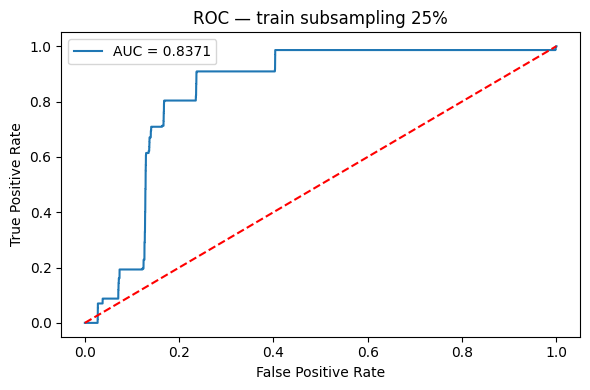

  → AUC: 0.8371

Ratio: 50%  |  train dir: 3ed_trai_h_graphs_hetero_sub50
  96 training graph(s) loaded.
  Epoch   1/50  loss=0.080249
  Epoch  10/50  loss=0.022364
  Epoch  20/50  loss=0.017261
  Epoch  30/50  loss=0.015546
  Epoch  40/50  loss=0.014945
  Epoch  50/50  loss=0.014642
  Test — benign: 571,791  attack: 855


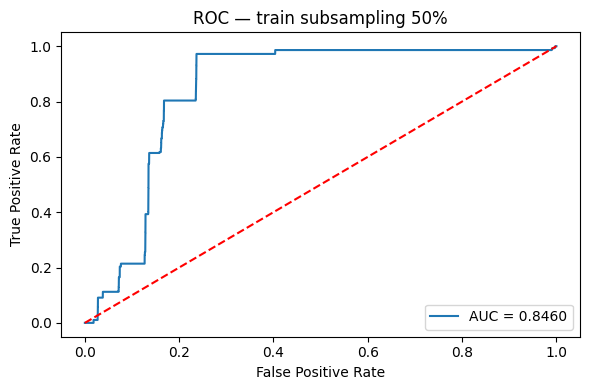

  → AUC: 0.8460

Ratio: 75%  |  train dir: 3ed_trai_h_graphs_hetero_sub75
  96 training graph(s) loaded.
  Epoch   1/50  loss=0.073120
  Epoch  10/50  loss=0.017143
  Epoch  20/50  loss=0.013739
  Epoch  30/50  loss=0.012647
  Epoch  40/50  loss=0.011911
  Epoch  50/50  loss=0.011561
  Test — benign: 571,791  attack: 855


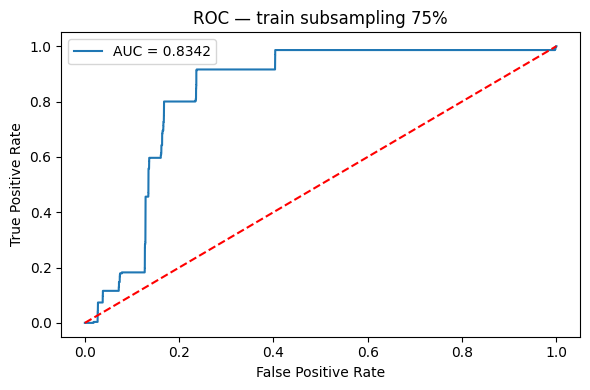

  → AUC: 0.8342

Ratio: 100% (no subsampling)  |  train dir: 3ed_trai_h_graphs_hetero_graphs
  192 training graph(s) loaded.
  Epoch   1/50  loss=0.042923
  Epoch  10/50  loss=0.009917
  Epoch  20/50  loss=0.009137
  Epoch  30/50  loss=0.008806
  Epoch  40/50  loss=0.008653
  Epoch  50/50  loss=0.008286
  Test — benign: 571,791  attack: 855


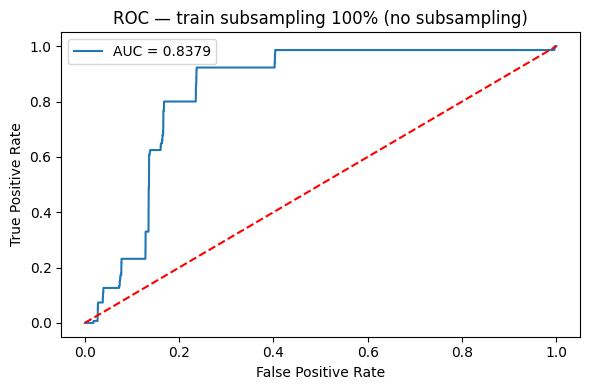

  → AUC: 0.8379

Experiment complete.
AUC by ratio: {25: '0.8371', 50: '0.8460', 75: '0.8342', 100: '0.8379'}


In [4]:
results_auc = []

# Load test graphs once — reused for every ratio (full set, no subsampling).
print(f"Loading test graphs from '{TEST_DIR}' …")
test_graphs = load_graphs(TEST_DIR)
print(f"  {len(test_graphs)} test graph(s) loaded.\n")

for ratio in RATIOS:
    td = train_dir(ratio)
    label = f"{ratio}%" if ratio < 100 else "100% (no subsampling)"
    print(f"{'='*55}")
    print(f"Ratio: {label}  |  train dir: {td}")
    print(f"{'='*55}")

    train_graphs = load_graphs(td)
    print(f"  {len(train_graphs)} training graph(s) loaded.")

    # Fresh model for each ratio so results are independent.
    in_channels = train_graphs[0]['ip'].x.shape[1]
    model = HeteroGAE(hidden_channels=128, out_channels=in_channels).to(device)

    train_gae(model, train_graphs, epochs=50, device=device)

    metrics = evaluate_anomaly_detection(
        model, test_graphs, device=device, label=label
    )
    results_auc.append(metrics['auc'])
    print(f"  → AUC: {metrics['auc']:.4f}\n")

print("Experiment complete.")
print("AUC by ratio:", dict(zip(RATIOS, [f'{a:.4f}' for a in results_auc])))


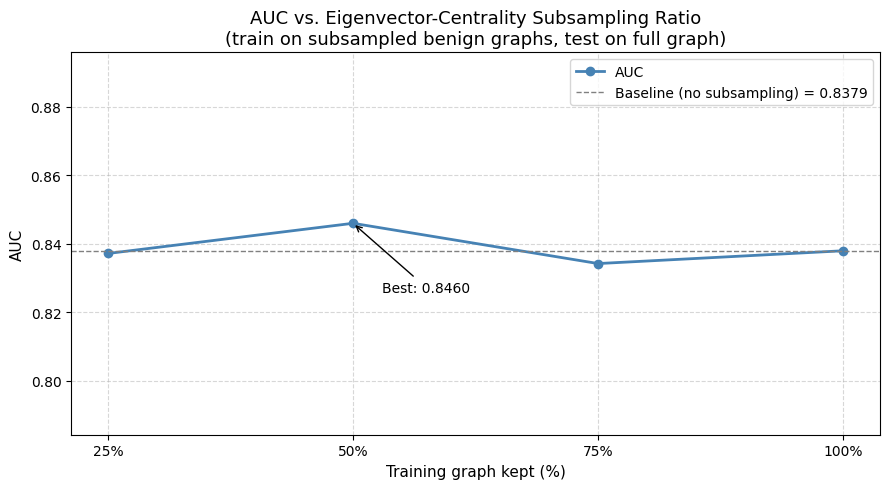


Summary:
   25%  AUC = 0.8371
   50%  AUC = 0.8460 ← best
   75%  AUC = 0.8342
  100%  AUC = 0.8379


In [5]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(RATIOS, results_auc, marker='o', color='steelblue', linewidth=2, label='AUC')
ax.axhline(results_auc[-1], color='gray', linestyle='--', linewidth=1,
           label=f'Baseline (no subsampling) = {results_auc[-1]:.4f}')

best_idx = int(np.argmax(results_auc))
ax.annotate(f"Best: {results_auc[best_idx]:.4f}",
            xy=(RATIOS[best_idx], results_auc[best_idx]),
            xytext=(RATIOS[best_idx] + 3, results_auc[best_idx] - 0.02),
            arrowprops=dict(arrowstyle='->', color='black'))

ax.set_title('AUC vs. Eigenvector-Centrality Subsampling Ratio\n'
             '(train on subsampled benign graphs, test on full graph)', fontsize=13)
ax.set_xlabel('Training graph kept (%)', fontsize=11)
ax.set_ylabel('AUC', fontsize=11)
ax.set_xticks(RATIOS)
ax.set_xticklabels([f'{r}%' for r in RATIOS])
ax.set_ylim(max(0, min(results_auc) - 0.05), min(1.0, max(results_auc) + 0.05))
ax.grid(True, linestyle='--', alpha=0.5)
ax.legend()
plt.tight_layout()
plt.savefig("subsampling_auc_comparison.png", dpi=150)
plt.show()

print("\nSummary:")
for ratio, auc in zip(RATIOS, results_auc):
    marker = " ← best" if auc == max(results_auc) else ""
    print(f"  {ratio:3d}%  AUC = {auc:.4f}{marker}")
